The project aims to develop a machine learning model to predict option prices by combining traditional financial models with sentiment analysis of news articles. The model will leverage options market data, stock prices, and sentiment analysis to improve pricing accuracy.

Introduction:
https://www.sciencedirect.com/science/article/pii/S0304405X24001235
https://thesis.eur.nl/pub/67130/Thesis_MvLent_Final.pdf

Preprocessing the data

In [ ]:
#need to merge the data for the options and stock prices here using CUSIP number and ticker symbol
# Ensure data is sorted by time to maintain temporal integrity
#make it one dataframe and name the final final version as df
#list the column names for df to be used in model

In [ ]:
import pandas as pd
# Read data
options_df = pd.read_csv('options_data.csv')
stock_df = pd.read_csv('stock_price_data.csv')

<ipython-input-123-195979adb81e>:3: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  options_df = pd.read_csv('options_data.csv')


In [ ]:
print("Options Data Head:", options_df.head())
print("Stock Data Head:", stock_df.head())

Options Data Head:     secid        date      exdate cp_flag  strike_price  best_bid  best_offer  \
0  101062  2022-08-31  2022-09-02       C        200000    171.80      175.95   
1  101062  2022-08-31  2022-09-02       C        210000    161.80      166.00   
2  101062  2022-08-31  2022-09-02       C        220000    152.00      155.95   
3  101062  2022-08-31  2022-09-02       C        230000    142.65      146.05   
4  101062  2022-08-31  2022-09-02       C        240000    131.90      136.05   

   impl_volatility     delta     gamma      vega     theta   optionid  \
0         3.878386  0.989829  0.000253  0.748830 -270.0063  148697139   
1         3.632699  0.988593  0.000298  0.827691 -279.4935  148596547   
2         3.447286  0.986181  0.000371  0.978038 -312.6895  148596548   
3         3.486804  0.977678  0.000552  1.472209 -473.4311  148596549   
4         2.937355  0.983955  0.000495  1.110269 -303.5500  148596550   

   forward_price     cusip ticker  index_flag     issue

In [ ]:
# Rename columns
options_df.rename(columns={'cusip': 'CUSIP', 'ticker': 'TICKER'}, inplace=True)
stock_df.rename(columns={'cusip': 'CUSIP', 'ticker': 'TICKER'}, inplace=True)

In [ ]:
# Clean CUSIP and TICKER
options_df['CUSIP'] = options_df['CUSIP'].astype(str).str.strip().str.upper()
options_df['TICKER'] = options_df['TICKER'].astype(str).str.strip().str.upper()
stock_df['CUSIP'] = stock_df['CUSIP'].astype(str).str.strip().str.upper()
stock_df['TICKER'] = stock_df['TICKER'].astype(str).str.strip().str.upper()

In [ ]:
options_df['date'] = pd.to_datetime(options_df['date'])
stock_df['date'] = pd.to_datetime(stock_df['date'])

In [ ]:
options_df['option_price'] = (options_df['best_bid'] + options_df['best_offer']) / 2

In [ ]:
print("\nMissing values in options data:\n", options_df.isnull().sum())
print("\nMissing values in stock data:\n", stock_df.isnull().sum())

print("\nDuplicate entries in options data:", options_df.duplicated(subset=['CUSIP', 'TICKER', 'date']).sum())
print("\nDuplicate entries in stock data:", stock_df.duplicated(subset=['CUSIP', 'TICKER', 'date']).sum())



Missing values in options data:
 secid                    0
date                     0
exdate                   0
cp_flag                  0
strike_price             0
best_bid                 0
best_offer               0
impl_volatility     210964
delta               210964
gamma               210964
vega                210964
theta               210964
optionid                 0
forward_price      1603862
CUSIP                    0
TICKER                   0
index_flag               0
issuer                   0
exercise_style           0
option_price             0
dtype: int64

Missing values in stock data:
 PERMNO    0
date      0
TICKER    0
CUSIP     0
PRC       0
dtype: int64

Duplicate entries in options data: 1603102

Duplicate entries in stock data: 0


In [ ]:
# Merge data
merged_df = pd.merge(options_df, stock_df, on=['CUSIP', 'TICKER', 'date'], how='inner')

In [ ]:
# Print merged data info
print("\nMerged Data Head:\n", merged_df.head())
print("\nSize of the dataset (row, col): ", merged_df.shape)


Merged Data Head:
     secid       date      exdate cp_flag  strike_price  best_bid  best_offer  \
0  101062 2022-08-31  2022-09-02       C        200000    171.80      175.95   
1  101062 2022-08-31  2022-09-02       C        210000    161.80      166.00   
2  101062 2022-08-31  2022-09-02       C        220000    152.00      155.95   
3  101062 2022-08-31  2022-09-02       C        230000    142.65      146.05   
4  101062 2022-08-31  2022-09-02       C        240000    131.90      136.05   

   impl_volatility     delta     gamma  ...   optionid  forward_price  \
0         3.878386  0.989829  0.000253  ...  148697139            NaN   
1         3.632699  0.988593  0.000298  ...  148596547            NaN   
2         3.447286  0.986181  0.000371  ...  148596548            NaN   
3         3.486804  0.977678  0.000552  ...  148596549            NaN   
4         2.937355  0.983955  0.000495  ...  148596550            NaN   

      CUSIP  TICKER index_flag     issuer  exercise_style op

In [ ]:
# drop forward price
merged_df.drop(columns=['forward_price'], inplace=True)


In [ ]:
# Only drop rows if 'CUSIP', 'TICKER', 'date', and 'PRC' are missing
merged_df.dropna(inplace=True)

# Now sort again
merged_df.sort_values(by=['CUSIP', 'TICKER', 'date'], inplace=True)

# Check if rows are still present
print("\nCleaned Merged Data Head:\n", merged_df.head())
print("\nFinal Dataset Size:", merged_df.shape)


Cleaned Merged Data Head:
     secid       date      exdate cp_flag  strike_price  best_bid  best_offer  \
0  101062 2022-08-31  2022-09-02       C        200000    171.80      175.95   
1  101062 2022-08-31  2022-09-02       C        210000    161.80      166.00   
2  101062 2022-08-31  2022-09-02       C        220000    152.00      155.95   
3  101062 2022-08-31  2022-09-02       C        230000    142.65      146.05   
4  101062 2022-08-31  2022-09-02       C        240000    131.90      136.05   

   impl_volatility     delta     gamma  ...     theta   optionid     CUSIP  \
0         3.878386  0.989829  0.000253  ... -270.0063  148697139  00724F10   
1         3.632699  0.988593  0.000298  ... -279.4935  148596547  00724F10   
2         3.447286  0.986181  0.000371  ... -312.6895  148596548  00724F10   
3         3.486804  0.977678  0.000552  ... -473.4311  148596549  00724F10   
4         2.937355  0.983955  0.000495  ... -303.5500  148596550  00724F10   

  TICKER index_flag   

In [ ]:
print("\nSummary statistics\n", merged_df.describe())


Summary statistics
               secid                           date  strike_price  \
count  1.120249e+06                        1120249  1.120249e+06   
mean   1.093004e+05  2023-03-09 00:52:45.933288704  3.615141e+05   
min    1.010620e+05            2022-08-31 00:00:00  5.000000e+03   
25%    1.010620e+05            2022-12-01 00:00:00  2.250000e+05   
50%    1.154220e+05            2023-03-13 00:00:00  3.400000e+05   
75%    1.154220e+05            2023-06-20 00:00:00  4.700000e+05   
max    1.154220e+05            2023-08-31 00:00:00  1.325000e+06   
std    7.099362e+03                            NaN  1.968024e+05   

           best_bid    best_offer  impl_volatility         delta  \
count  1.120249e+06  1.120249e+06     1.120249e+06  1.120249e+06   
mean   6.261472e+01  6.423380e+01     6.173514e-01  7.294965e-02   
min    0.000000e+00  1.000000e-02     1.366610e-01 -9.998650e-01   
25%    9.200000e-01  1.210000e+00     3.920550e-01 -2.097430e-01   
50%    1.760000e+01  1.835

In [ ]:
merged_df.to_csv('merged_data.csv', index=False)
print("\nMerged dataset saved as 'merged_data.csv'.")


Merged dataset saved as 'merged_data.csv'.


Adding sentiment to the data

https://thesis.eur.nl/pub/67130/Thesis_MvLent_Final.pdf


In [ ]:
#make a copy of df with df1 and add sentiment values
#add a google drive link here with a way to download the .csv file for the sentiment data
#make it one dataframe and name the final final version as df

XGBoost without Sentiment

In [ ]:
#libraries
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv('merged_data.csv')

In [ ]:
# Define feature columns and target column (subject to change based on csv file)p_flag                  0
features = ['delta', 'gamma', 'vega', 'theta', 'optionid', 'CUSIP',  'strike_price', 'TICKER', 'issuer','PERMNO', 'PRC','date', 'exdate','cp_flag']
target = 'option_price'

In [ ]:
# Split data into features (X) and target (y)
X = df[features]
y = df[target]

In [ ]:
# Split into training and testing sets
split_index = int(0.8 * len(df))
X_train_nos, X_test_nos = X.iloc[:split_index], X.iloc[split_index:]
y_train_nos, y_test_nos = y.iloc[:split_index], y.iloc[split_index:]

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ['CUSIP', 'TICKER', 'issuer', 'PERMNO', 'date', 'exdate']
numerical_features = ['delta', 'gamma', 'vega', 'theta', 'optionid', 'strike_price', 'PRC']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),  # Changed from 'features'
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)])

X_train_scaled_nos = preprocessor.fit_transform(X_train_nos)
X_test_scaled_nos = preprocessor.transform(X_test_nos)

In [ ]:
# Define and train XGBoost model
xgb_model_nos = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5)
xgb_model_nos.fit(X_train_scaled_nos, y_train_nos)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [ ]:
# Make predictions
y_pred_nos = xgb_model_nos.predict(X_test_scaled_nos)

In [ ]:
# Evaluate model performance
mse_nos = mean_squared_error(y_test_nos, y_pred_nos)
rmse_nos = np.sqrt(mse_nos)
print(f'Root Mean Squared Error: {rmse_nos}')

Root Mean Squared Error: 12.777285973240648


<Figure size 1000x600 with 0 Axes>

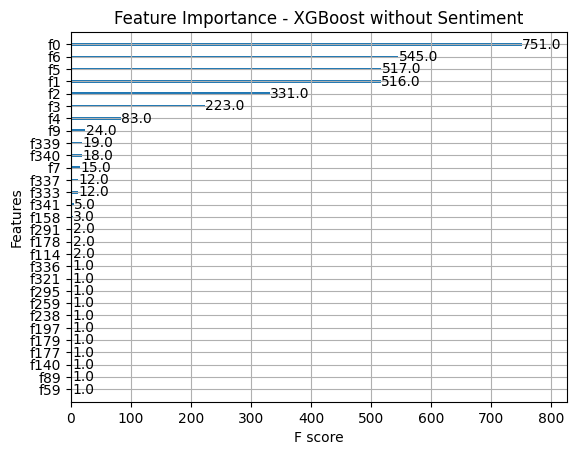

In [ ]:
# Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model_nos)
plt.title("Feature Importance - XGBoost without Sentiment")
plt.show()

XGBoost with Sentiment

In [ ]:
# Define feature columns and target column (subject to change based on csv file)p_flag                  0
features = ['delta', 'gamma', 'vega', 'theta', 'optionid', 'CUSIP',  'strike_price', 'TICKER', 'issuer','PERMNO', 'PRC','date', 'exdate','cp_flag']
target = 'option_price'

In [ ]:
# Split data into features (X) and target (y)
X1 = df1[features]
y1 = df1[target]

NameError: name 'df1' is not defined

In [ ]:
# Split into training and testing sets
split_index = int(0.8 * len(df))
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

#scale after splitting
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Define and train XGBoost model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5)
xgb_model.fit(X_train, y_train)

In [ ]:
# Make predictions
y_pred = xgb_model.predict(X_test)

In [ ]:
# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error: {rmse}')

In [ ]:
# Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model)
plt.title("Feature Importance - XGBoost with Sentiment")
plt.show()

NameError: name 'xgb_model' is not defined

<Figure size 1000x600 with 0 Axes>

Comparison Stats for sentiment

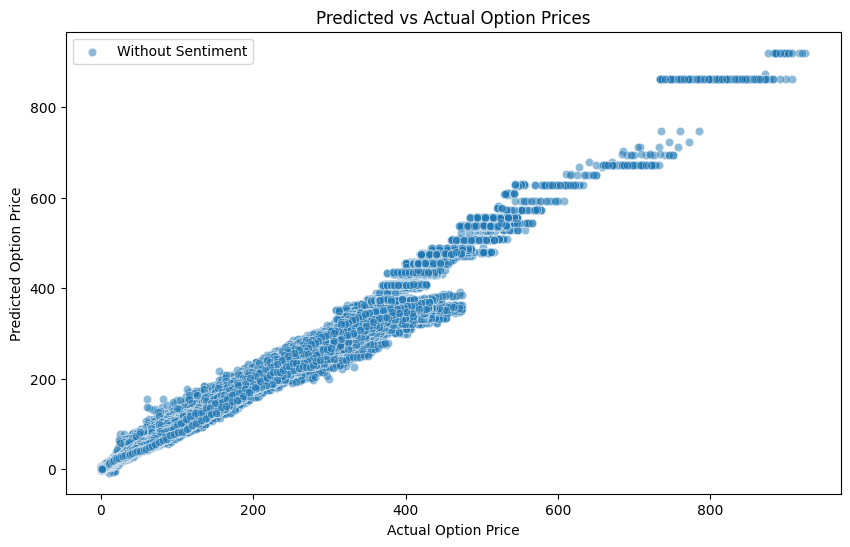

In [ ]:
# Plot predictions vs actual values
plt.figure(figsize=(10, 6))
# sns.scatterplot(x=y_test, y=y_pred, label='With Sentiment', alpha=0.5)
sns.scatterplot(x=y_test_nos, y=y_pred_nos, label='Without Sentiment', alpha=0.5)
plt.xlabel("Actual Option Price")
plt.ylabel("Predicted Option Price")
plt.title("Predicted vs Actual Option Prices")
plt.legend()
plt.show()

In [ ]:
summary_stats = pd.DataFrame({
    "Model": ["Without Sentiment"],
    "MSE": [mse_nos],
    "RMSE": [rmse_nos]
})
print(summary_stats)

               Model         MSE       RMSE
0  Without Sentiment  163.259037  12.777286
